<h3 style="color: #e0e0ff; font-style: italic;">VCLMMF (VAE & Contrastive Learning Multimodal Fusion) Model for Multimodal Fake News Detection</h3>

---
VCLMMF leverages variational autoencoding and bidirectional contrastive learning to align text and image representations in a shared latent space, optimized for fake news classification.

**Imports and Setup**

In [1]:
# Core
import time
import os
from PIL import Image
from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from torchvision import models
from transformers import XLMRobertaModel, XLMRobertaTokenizer

from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, roc_auc_score, precision_recall_fscore_support
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, os.path.abspath('../../src'))
from data_pipeline import M4FCDataPipeline
from model_registry import update_registry


c:\Users\SAFAE ERAJI\Desktop\M2\Stage PFE\multimodal_fake_news_detection\venv_ai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Device: {device}")

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
set_seed(42)

os.makedirs('../../models/vclmmf', exist_ok=True)
os.makedirs('../../reports/vclmmf/figures', exist_ok=True)
os.makedirs('../../reports/vclmmf/metrics', exist_ok=True)
sns.set_palette('husl')


🖥️  Device: cuda


**Data Loading and Preparation**

In [3]:
class VCLMMFDataset(Dataset):
    def __init__(self, df, tokenizer, max_text_length=128, image_size=(224, 224), word_count_mean=None, word_count_std=None):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_text_length = max_text_length
        self.image_size = image_size
        self.text_field = 'multilingual_claim'
        if word_count_mean is not None:
            self.word_count_mean = word_count_mean
        else:
            self.word_count_mean = self.df['claim_word_count'].mean() if 'claim_word_count' in self.df.columns else 0.0
        if word_count_std is not None:
            self.word_count_std = word_count_std
        else:
            self.word_count_std = self.df['claim_word_count'].std() if 'claim_word_count' in self.df.columns else 1.0
            if self.word_count_std == 0 or pd.isna(self.word_count_std):
                self.word_count_std = 1.0
        print(f"Using text field: {self.text_field}")
    
    def __len__(self):
        return len(self.df)
    
    def load_image(self, image_path):
        try: 
            if os.path.exists(image_path):
                image = Image.open(image_path).convert('RGB')
                image = image.resize(self.image_size)
                image = torch.from_numpy(np.array(image)).float().permute(2, 0, 1) / 255.0
                mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
                std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
                image = (image - mean) / std
                return image
            else:
                return torch.zeros(3, self.image_size[0], self.image_size[1])
        except Exception as e:
            return torch.zeros(3, self.image_size[0], self.image_size[1])
            
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = str(row[self.text_field]) if pd.notna(row[self.text_field]) else ""
        encoding = self.tokenizer(
            text,
            max_length=self.max_text_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        image_path = row['full_image_path'] if pd.notna(row['full_image_path']) else ""
        image = self.load_image(image_path)
        
        is_ai = float(row['is_ai_generated']) if pd.notna(row['is_ai_generated']) else 0.0
        img_exists = float(row['image_exists']) if pd.notna(row['image_exists']) else 0.0
        word_count = float(row['claim_word_count']) if pd.notna(row['claim_word_count']) else 0.0
        word_count = (word_count - self.word_count_mean) / self.word_count_std
        manipulated = float(row['is_manipulated_fake']) if pd.notna(row['is_manipulated_fake']) else 0.0
        use_caption = float(row['use_true_caption']) if pd.notna(row['use_true_caption']) else 0.0
        
        metadata = torch.tensor([is_ai, img_exists, word_count, manipulated, use_caption], dtype=torch.float)
        label = torch.tensor(row['target'], dtype=torch.long)
        
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'image': image,
            'metadata': metadata,
            'label': label,
            'text': text,
            'image_path': image_path
        }


In [4]:
tokenizer = XLMRobertaTokenizer.from_pretrained('xlm-roberta-base')

# Aligned DataSplit to match exact HMCAN baseline folds
pipeline = M4FCDataPipeline(csv_path='../../data/M4FC.csv', target_col='target', random_state=42)
df = pipeline._load_data()

train_df, val_df, test_df = pipeline.split_dataframe(df)
print(f"✓ Aligned Split data: Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")

word_count_mean = train_df['claim_word_count'].mean() if 'claim_word_count' in train_df.columns else 0.0
word_count_std = train_df['claim_word_count'].std() if 'claim_word_count' in train_df.columns else 1.0
if word_count_std == 0 or pd.isna(word_count_std):
    word_count_std = 1.0

train_dataset = VCLMMFDataset(train_df, tokenizer, word_count_mean=word_count_mean, word_count_std=word_count_std)
val_dataset = VCLMMFDataset(val_df, tokenizer, word_count_mean=word_count_mean, word_count_std=word_count_std)
test_dataset = VCLMMFDataset(test_df, tokenizer, word_count_mean=word_count_mean, word_count_std=word_count_std)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)


✓ Aligned Split data: Train=3462, Val=743, Test=743
Using text field: multilingual_claim
Using text field: multilingual_claim
Using text field: multilingual_claim


**VCLMMF Model Architecture (VAE + Contrastive Fusion)**

In [5]:
class VCLMMFModel(nn.Module):
    def __init__(self, text_encoder, image_encoder, latent_dim=128, num_classes=2):
        super().__init__()
        self.text_encoder = text_encoder
        self.image_encoder = image_encoder
        self.latent_dim = latent_dim
        
        self.text_project = nn.Sequential(
            nn.Linear(768, 384),
            nn.ReLU()
        )
        self.text_mu = nn.Linear(384, latent_dim)
        self.text_logvar = nn.Linear(384, latent_dim)
        
        self.image_project = nn.Sequential(
            nn.Linear(2048, 512),
            nn.ReLU()
        )
        self.image_mu = nn.Linear(512, latent_dim)
        self.image_logvar = nn.Linear(512, latent_dim)
        
        self.text_decode = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 768)
        )
        self.image_decode = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 2048)
        )
        
        self.metadata_encoder = nn.Sequential(
            nn.Linear(5, 32),
            nn.ReLU(),
            nn.Linear(32, 64)
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(latent_dim * 2 + 64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
        
        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print("✅ VCLMMF Model ready!")
        print(f"   Total params: {total:,}")
        print(f"   Trainable: {trainable:,} ({(trainable/total)*100:.1f}%)")
        
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, input_ids, attention_mask, images, metadata):
        text_outputs = self.text_encoder(input_ids, attention_mask=attention_mask)
        text_feats = text_outputs.pooler_output
        image_feats = self.image_encoder(images)
            
        text_projected = self.text_project(text_feats)
        mu_t = self.text_mu(text_projected)
        logvar_t = self.text_logvar(text_projected)
        z_t = self.reparameterize(mu_t, logvar_t)
        
        image_projected = self.image_project(image_feats)
        mu_i = self.image_mu(image_projected)
        logvar_i = self.image_logvar(image_projected)
        z_i = self.reparameterize(mu_i, logvar_i)
        
        recon_t = self.text_decode(z_t)
        recon_i = self.image_decode(z_i)
        
        meta_feats = self.metadata_encoder(metadata)
        fused = torch.cat([z_t, z_i, meta_feats], dim=-1)
        logits = self.classifier(fused)
        
        return logits, mu_t, logvar_t, z_t, recon_t, text_feats, mu_i, logvar_i, z_i, recon_i, image_feats


**Training Setup**

In [6]:
text_encoder = XLMRobertaModel.from_pretrained('xlm-roberta-base', use_safetensors=True)
for name, param in text_encoder.named_parameters():
    if "layer.11" in name or "pooler" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

image_encoder = models.resnet50(weights='IMAGENET1K_V1')
image_encoder.fc = nn.Identity()
for name, param in image_encoder.named_parameters():
    if "layer4" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4345.34it/s]
[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


**Training Pipeline**

In [7]:
class VCLMMFTrainer:
    def __init__(self, model, train_loader, val_loader, test_loader, device='cuda'):
        self.model = model.to(device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader = test_loader
        self.device = device
        
        self.optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(self.optimizer, T_max=20)
        
        # Robust class weights
        num_real, num_fake = 0, 0
        for batch in self.train_loader:
            num_real += (batch['label'] == 0).sum().item()
            num_fake += (batch['label'] == 1).sum().item()
        weight_real = 1.0 / num_real if num_real > 0 else 1.0
        weight_fake = 1.0 / num_fake if num_fake > 0 else 1.0
        weights = torch.tensor([weight_real, weight_fake], dtype=torch.float).to(device)
        weights = weights / weights.sum()
        print(f"⚖️ Using Class Weights -> Real: {weights[0]:.4f}, Fake: {weights[1]:.4f}")
        self.criterion = nn.CrossEntropyLoss(weight=weights)
        
        self.metrics_history = {
            'train_loss': [], 'val_loss': [],
            'train_acc': [], 'val_acc': [],
            'precision': [], 'recall': [], 'f1': [],
            'auc': []
        }
        self.best_model_path = '../../models/vclmmf/best_vclmmf_model.pth'
        self.best_val_f1 = 0.0
        self.last_loss_breakdown = {}
        
    def compute_loss(self, outputs, label):
        logits, mu_t, logvar_t, z_t, recon_t, text_feats, mu_i, logvar_i, z_i, recon_i, image_feats = outputs
        class_loss = self.criterion(logits, label)
        
        recon_loss_t = F.mse_loss(recon_t, text_feats)
        recon_loss_i = F.mse_loss(recon_i, image_feats)
        recon_loss = recon_loss_t + recon_loss_i
        
        kl_t = -0.5 * torch.mean(1 + logvar_t - mu_t.pow(2) - logvar_t.exp())
        kl_i = -0.5 * torch.mean(1 + logvar_i - mu_i.pow(2) - logvar_i.exp())
        kl_loss = kl_t + kl_i
        
        z_t_norm = F.normalize(z_t, p=2, dim=1)
        z_i_norm = F.normalize(z_i, p=2, dim=1)
        
        temperature = 0.07
        sim_matrix = torch.matmul(z_t_norm, z_i_norm.T) / temperature
        
        batch_size = z_t.size(0)
        contrast_labels = torch.arange(batch_size).to(self.device)
        
        loss_t2i = F.cross_entropy(sim_matrix, contrast_labels)
        loss_i2t = F.cross_entropy(sim_matrix.T, contrast_labels)
        contrast_loss = (loss_t2i + loss_i2t) / 2.0

        total_loss = (class_loss + 
                      0.001 * recon_loss + 
                      0.01 * kl_loss +          
                      0.1 * contrast_loss)    
        
        self.last_loss_breakdown = {
            'class_loss': class_loss.item(),
            'recon_loss': recon_loss.item(),
            'kl_loss': kl_loss.item(),
            'contrast_loss': contrast_loss.item(),
            'total_loss': total_loss.item()
        }
        return total_loss
        
    def train_epoch(self):
        self.model.train()
        total_loss = 0
        predictions, labels = [], []
        
        progress_bar = tqdm(self.train_loader, desc='Training')
        for batch in progress_bar:
            input_ids = batch['input_ids'].to(self.device)
            attention_mask = batch['attention_mask'].to(self.device)
            images = batch['image'].to(self.device)
            metadata = batch['metadata'].to(self.device)
            label = batch['label'].to(self.device)
            
            self.optimizer.zero_grad()
            outputs = self.model(input_ids, attention_mask, images, metadata)
            loss = self.compute_loss(outputs, label)
            
            loss.backward()
            nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()
            
            total_loss += loss.item() * input_ids.size(0)
            logits = outputs[0]
            _, preds = torch.max(logits, 1)
            predictions.extend(preds.cpu().numpy())
            labels.extend(label.cpu().numpy())
            
        self.scheduler.step()
        avg_loss = total_loss / len(self.train_loader.dataset)
        accuracy = accuracy_score(labels, predictions)
        return avg_loss, accuracy
        
    @torch.no_grad()
    def evaluate(self, data_loader, mode='val'):
        self.model.eval()
        total_loss = 0
        predictions, probabilities, labels = [], [], []
        
        for batch in tqdm(data_loader, desc=f'Evaluating {mode}'):
            input_ids = batch['input_ids'].to(self.device)
            attention_mask = batch['attention_mask'].to(self.device)
            images = batch['image'].to(self.device)
            metadata = batch['metadata'].to(self.device)
            label = batch['label'].to(self.device)
            
            outputs = self.model(input_ids, attention_mask, images, metadata)
            loss = self.compute_loss(outputs, label)
            
            total_loss += loss.item() * input_ids.size(0)
            logits = outputs[0]
            probs = F.softmax(logits, dim=1)[:, 1]
            _, preds = torch.max(logits, 1)
            
            predictions.extend(preds.cpu().numpy())
            probabilities.extend(probs.cpu().numpy())
            labels.extend(label.cpu().numpy())
            
        avg_loss = total_loss / len(data_loader.dataset)
        accuracy = accuracy_score(labels, predictions)
        # Changed to binary F1-score evaluation to remain strictly fair and aligned with other notebooks!
        precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary', zero_division=0)
        try:
            auc_score = roc_auc_score(labels, probabilities)
        except:
            auc_score = 0.5
            
        return {
            'loss': avg_loss, 'accuracy': accuracy, 'precision': precision,
            'recall': recall, 'f1': f1, 'auc': auc_score,
            'predictions': predictions, 'true_labels': labels, 'probabilities': probabilities
        }

    def train(self, epochs=5, early_stopping_patience=3):
        print("Starting VCLMMF Training Pipeline...")
        print("=" * 50)
        epochs_no_improve = 0
        for epoch in range(epochs):
            train_loss, train_acc = self.train_epoch()
            val_metrics = self.evaluate(self.val_loader, 'val')
            
            self.metrics_history['train_loss'].append(train_loss)
            self.metrics_history['train_acc'].append(train_acc)
            self.metrics_history['val_loss'].append(val_metrics['loss'])
            self.metrics_history['val_acc'].append(val_metrics['accuracy'])
            self.metrics_history['precision'].append(val_metrics['precision'])
            self.metrics_history['recall'].append(val_metrics['recall'])
            self.metrics_history['f1'].append(val_metrics['f1'])
            self.metrics_history['auc'].append(val_metrics['auc'])
            
            print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Val F1: {val_metrics['f1']:.4f}, Val Loss: {val_metrics['loss']:.4f}")
            
            if val_metrics['f1'] > self.best_val_f1:
                self.best_val_f1 = val_metrics['f1']
                epochs_no_improve = 0
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': self.model.state_dict(),
                    'optimizer_state_dict': self.optimizer.state_dict(),
                    'val_f1': val_metrics['f1'],
                    'val_loss': val_metrics['loss'],
                }, self.best_model_path)
                print(f"✓ Best model saved with val_f1: {val_metrics['f1']:.4f}")
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= early_stopping_patience:
                    print(f"Early stopping triggered! Best validation F1: {self.best_val_f1:.4f}")
                    break
        return self.metrics_history
        
    def test(self):
        print("\nRunning final test evaluation...")
        checkpoint = torch.load(self.best_model_path, weights_only=False)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        test_metrics = self.evaluate(self.test_loader, 'test')
        print(f"\nTest Set Results:")
        print(f"Accuracy: {test_metrics['accuracy']:.4f}")
        print(f"F1-Score: {test_metrics['f1']:.4f}")
        print(f"AUC-ROC: {test_metrics['auc']:.4f}")
        return test_metrics

In [8]:
print("\nCreating VCLMMF model...")
model = VCLMMFModel(text_encoder, image_encoder, latent_dim=128)
print(f"  - Running on: {device}")

print("\nTraining...")
trainer = VCLMMFTrainer(model, train_loader, val_loader, test_loader, device)
metrics_history = trainer.train(epochs=100, early_stopping_patience=10)

print("\nTesting...")
test_metrics = trainer.test()


Creating VCLMMF model...
✅ VCLMMF Model ready!
   Total params: 304,516,930
   Trainable: 25,608,450 (8.4%)
  - Running on: cuda

Training...
⚖️ Using Class Weights -> Real: 0.9411, Fake: 0.0589
Starting VCLMMF Training Pipeline...


Evaluating val: 100%|██████████| 47/47 [01:39<00:00,  2.11s/it]


Epoch 1/100 - Train Loss: 1.0497, Train Acc: 0.6904 | Val F1: 0.8538, Val Loss: 1.0459
✓ Best model saved with val_f1: 0.8538


Evaluating val: 100%|██████████| 47/47 [01:33<00:00,  1.98s/it]


Epoch 2/100 - Train Loss: 1.0189, Train Acc: 0.7458 | Val F1: 0.8891, Val Loss: 0.9911
✓ Best model saved with val_f1: 0.8891


...

Epoch 49/100 - Train Loss: 0.2715, Train Acc: 0.9991 | Val F1: 0.9694, Val Loss: 1.9531


Evaluating val: 100%|██████████| 47/47 [00:50<00:00,  1.08s/it]


Epoch 50/100 - Train Loss: 0.2637, Train Acc: 0.9994 | Val F1: 0.9707, Val Loss: 1.9377
Early stopping triggered! Best validation F1: 0.9713

Testing...

Running final test evaluation...


Evaluating test: 100%|██████████| 47/47 [00:50<00:00,  1.08s/it]


Test Set Results:
Accuracy: 0.9287
F1-Score: 0.9628
AUC-ROC: 0.5958


**Evaluation & Visualizations**

In [9]:
class VCLMMFVisualizer:
    @staticmethod
    def plot_training_history(metrics_history, save_path='../../reports/vclmmf/figures/training_history.png'):
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        axes[0, 0].plot(metrics_history['train_loss'], label='Train Loss')
        axes[0, 0].plot(metrics_history['val_loss'], label='Val Loss')
        axes[0, 0].set_title('Loss Over Time')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        axes[0, 1].plot(metrics_history['train_acc'], label='Train Acc')
        axes[0, 1].plot(metrics_history['val_acc'], label='Val Acc')
        axes[0, 1].set_title('Accuracy Over Time')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
        
        axes[1, 0].plot(metrics_history['f1'], label='F1-Score', marker='o')
        axes[1, 0].plot(metrics_history['auc'], label='AUC', marker='s')
        axes[1, 0].set_title('F1-Score and AUC')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
        
        axes[1, 1].plot(metrics_history['precision'], label='Precision', marker='^')
        axes[1, 1].plot(metrics_history['recall'], label='Recall', marker='v')
        axes[1, 1].set_title('Precision-Recall Trade-off')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
        plt.show()
        plt.close('all')
        print(f"✅ Training history plot saved to {save_path}")
    
    @staticmethod
    def plot_confusion_matrix(y_true, y_pred, save_path='../../reports/vclmmf/figures/confusion_matrix.png'):
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(7, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
        plt.title('Confusion Matrix - VCLMMF')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.tight_layout()
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
        plt.show()
        plt.close('all')
        print(f"Confusion matrix saved to {save_path}")

    @staticmethod
    def plot_roc_curve(y_true, y_prob, save_path='../../reports/vclmmf/figures/roc_curve.png'):
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(7, 5))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve - VCLMMF')
        plt.legend(loc='lower right')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
        plt.show()
        plt.close('all')
        print(f'ROC curve saved to {save_path}')

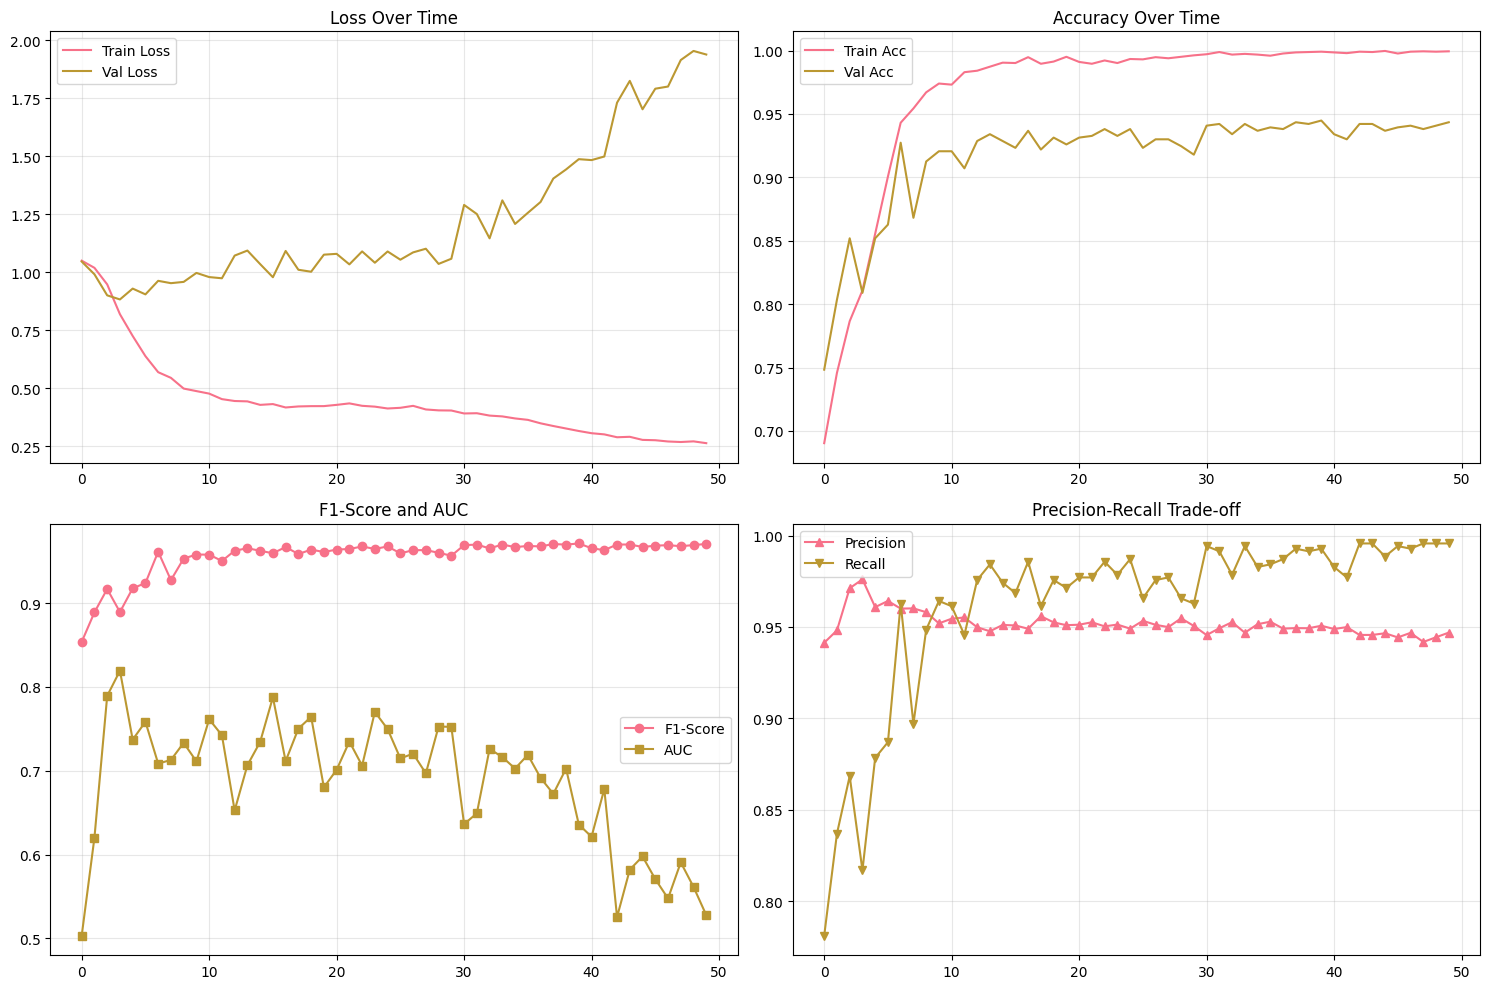

✅ Training history plot saved to ../../reports/vclmmf/figures/training_history.png


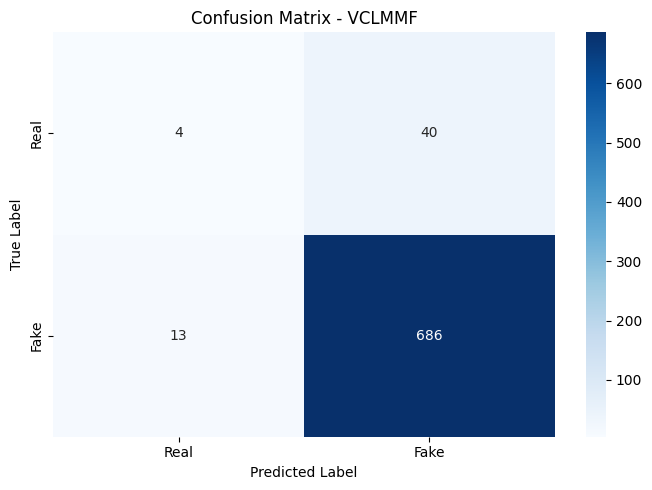

Confusion matrix saved to ../../reports/vclmmf/figures/confusion_matrix.png


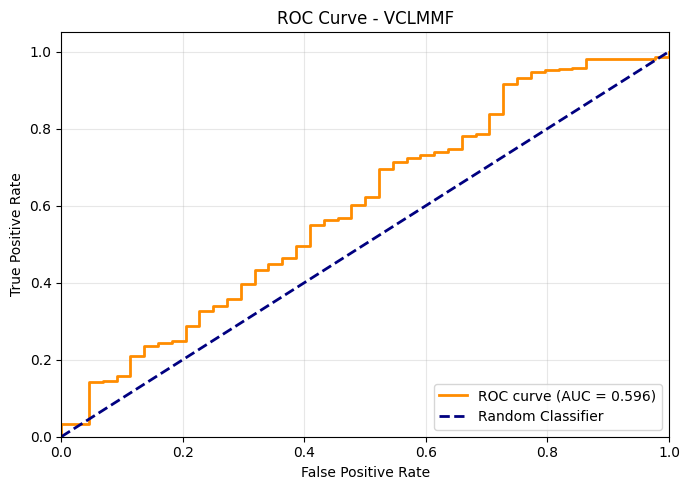

ROC curve saved to ../../reports/vclmmf/figures/roc_curve.png


In [10]:
visualizer = VCLMMFVisualizer()
visualizer.plot_training_history(metrics_history)
visualizer.plot_confusion_matrix(test_metrics['true_labels'], test_metrics['predictions'])
visualizer.plot_roc_curve(test_metrics['true_labels'], test_metrics['probabilities'])


**Reporting & Registry Update**

In [11]:
report_path = '../../reports/vclmmf/metrics/VCLMMF_Standard_Report.txt'
os.makedirs(os.path.dirname(report_path), exist_ok=True)

best_val_f1 = max(metrics_history['f1']) if metrics_history['f1'] else test_metrics['f1']
best_val_acc = max(metrics_history['val_acc']) if metrics_history['val_acc'] else test_metrics['accuracy']

with open(report_path, 'w', encoding='utf-8') as f:
    f.write('=' * 50 + '\n')
    f.write('VCLMMF MULTIMODAL FAKE NEWS DETECTION REPORT\n')
    f.write('=' * 50 + '\n\n')
    f.write(f'Epochs completed:  {len(metrics_history["train_loss"])}\n')
    f.write(f'Best Val F1:       {best_val_f1:.6f}\n')
    f.write(f'Best Val Accuracy: {best_val_acc:.6f}\n\n')
    f.write('TEST SET RESULTS\n' + '-' * 30 + '\n')
    f.write(f'  Accuracy:  {test_metrics["accuracy"]:.6f}\n')
    f.write(f'  Precision: {test_metrics["precision"]:.6f}\n')
    f.write(f'  Recall:    {test_metrics["recall"]:.6f}\n')
    f.write(f'  F1-Score:  {test_metrics["f1"]:.6f}\n')
    f.write(f'  AUC:       {test_metrics["auc"]:.6f}\n')

print(f'Report saved to {report_path}')

update_registry(
    name='VCLMMF',
    arch='VCLMMFModel',
    rel_path='models/vclmmf/best_vclmmf_model.pth',
    val_accuracy=float(best_val_acc),
    val_f1=float(best_val_f1),
    test_accuracy=float(test_metrics['accuracy']),
    test_f1=float(test_metrics['f1']),
    test_auc=float(test_metrics['auc']),
    latent_dim=128,
    num_classes=2
)


Report saved to ../../reports/vclmmf/metrics/VCLMMF_Standard_Report.txt
ℹ️  Registry unchanged — current champion 'Fusion - Metadata Fusion (MLP)' (acc=0.9462) leads 'VCLMMF' (acc=0.9448).


False